# Instant Model Experiments (Random Forest Regressor)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` as a continuous variable using a Random Forest Regressor.


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [7]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

df = df[feature_cols + [target_col]].copy()
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna()

print(f"Rows after cleaning: {len(df):,}")
display(df.head())


Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue
0,4225.0,7.669843,25.1,7.810250,0.001916,4
1,4225.0,7.669843,25.1,7.810250,0.001916,5
2,4096.0,6.835845,25.2,7.810250,0.001976,3
3,4096.0,6.835845,25.2,7.810250,0.001976,4
4,3969.0,7.039566,25.3,7.745967,0.001938,4


In [8]:
X = df[feature_cols]
y = df[target_col]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 1,449
Test size:  363


In [9]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    rf, 
    param_grid=param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=5, 
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV MAE: {-grid.best_score_:.3f}")

best_model = grid.best_estimator_

Best params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV MAE: 0.711



Test MAE: 0.737



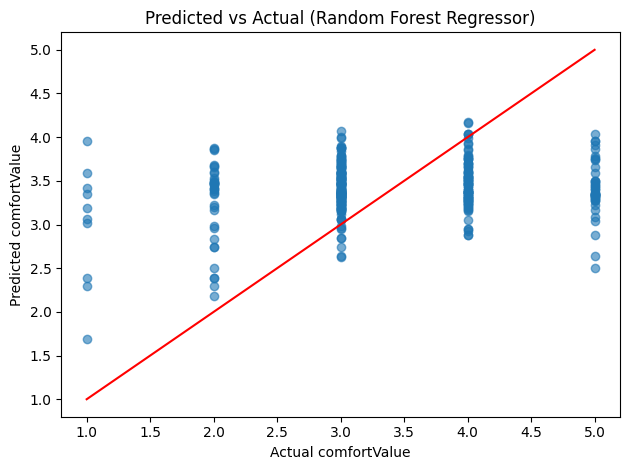

In [10]:
import matplotlib.pyplot as plt

test_preds = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, test_preds)
print(f"\nTest MAE: {test_mae:.3f}\n")

plt.scatter(y_test, test_preds, alpha=0.6)

min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.title('Predicted vs Actual (Random Forest Regressor)')
plt.xlabel('Actual comfortValue')
plt.ylabel('Predicted comfortValue')
plt.tight_layout()
plt.show()
